# **Modelling the Spread of Rent Inflation across States in the US through a Combined Spatial Analysis and Diffusion Modeling Approach**

<br>

<br>

*Week 5 - Time Series Modelling*

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

# Plot Specifications
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})


# Loading Dataset

In [30]:
# Getting cleaned and merged per state data
df_long = pd.read_csv("merged_df_final_long.csv")
# Getting Overview
df_long.head()

,Unnamed: 0,county_name,year,GDP_PI,housing_units,personal_income,house_size,rent,rent_growth
0,0.0,ALBANY,2001.0,13068721.0,133501.0,11476555.0,0.0,444.0,NaN
1,1.0,ALBANY,2002.0,13424897.0,133501.0,11476555.0,0.0,444.0,0.000000
2,2.0,ALBANY,2003.0,14257327.0,133501.0,11476555.0,0.0,444.0,0.000000
3,3.0,ALBANY,2004.0,14897956.0,133501.0,11476555.0,0.0,444.0,0.000000
4,4.0,ALBANY,2005.0,15541573.0,133501.0,11476555.0,0.0,569.0,0.281532


## Time Series Features

In [31]:
df_long["lag_1"] = (
    df_long.groupby(["county_name", "house_size"])["rent"]
    .shift(1)
)

df_long["lag_2"] = (
    df_long.groupby(["county_name", "house_size"])["rent"]
    .shift(2)
)
df_long.head()

,Unnamed: 0,county_name,year,GDP_PI,housing_units,personal_income,house_size,rent,rent_growth,lag_1,lag_2
0,0.0,ALBANY,2001.0,13068721.0,133501.0,11476555.0,0.0,444.0,NaN,NaN,NaN
1,1.0,ALBANY,2002.0,13424897.0,133501.0,11476555.0,0.0,444.0,0.000000,444.0,NaN
2,2.0,ALBANY,2003.0,14257327.0,133501.0,11476555.0,0.0,444.0,0.000000,444.0,444.0
3,3.0,ALBANY,2004.0,14897956.0,133501.0,11476555.0,0.0,444.0,0.000000,444.0,444.0
4,4.0,ALBANY,2005.0,15541573.0,133501.0,11476555.0,0.0,569.0,0.281532,444.0,444.0


# XGBoost Model

## Features and Target

In [32]:
# Features' Columns
features = [
    "GDP_PI",
    "housing_units",
    "personal_income",
    "house_size",
    "lag_1",
    "lag_2"
]

# Target Variable
target = "rent"

## Time Series Train-Test Split

In [33]:

df_model = df_long.dropna().copy()

# Data Partitions
train_df = df_model[df_model["year"] <= 2015]
test_df  = df_model[df_model["year"] > 2015]

# Training Features and Targets
X_train = train_df[features]
y_train = train_df[target]

# Testing Features and Targets
X_test = test_df[features]
y_test = test_df[target]

## Training XGBoost Model

In [34]:
# Model Initialization
model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fitting Model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

## Predictions

In [35]:
# Predictions
y_pred = model.predict(X_test)


In [36]:
# Performance Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

print(results)

  Metric       Value
0   RMSE  231.240965
1    MAE  117.932873
2     R²    0.885800


## Diagnostic Plots

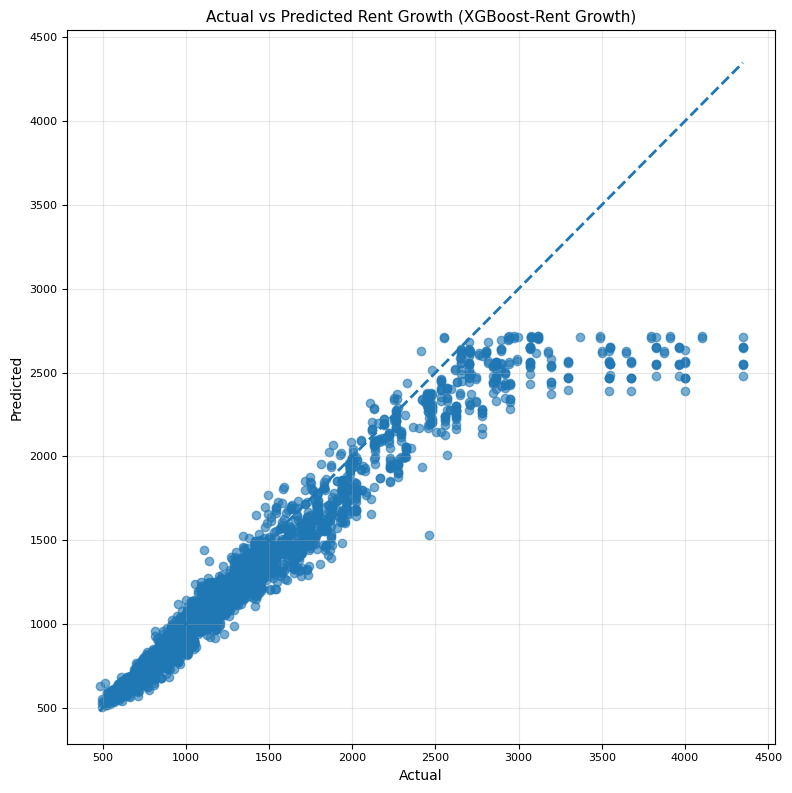

In [37]:
# Actual vs Predicted

plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Rent Growth (XGBoost-Rent Growth)")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

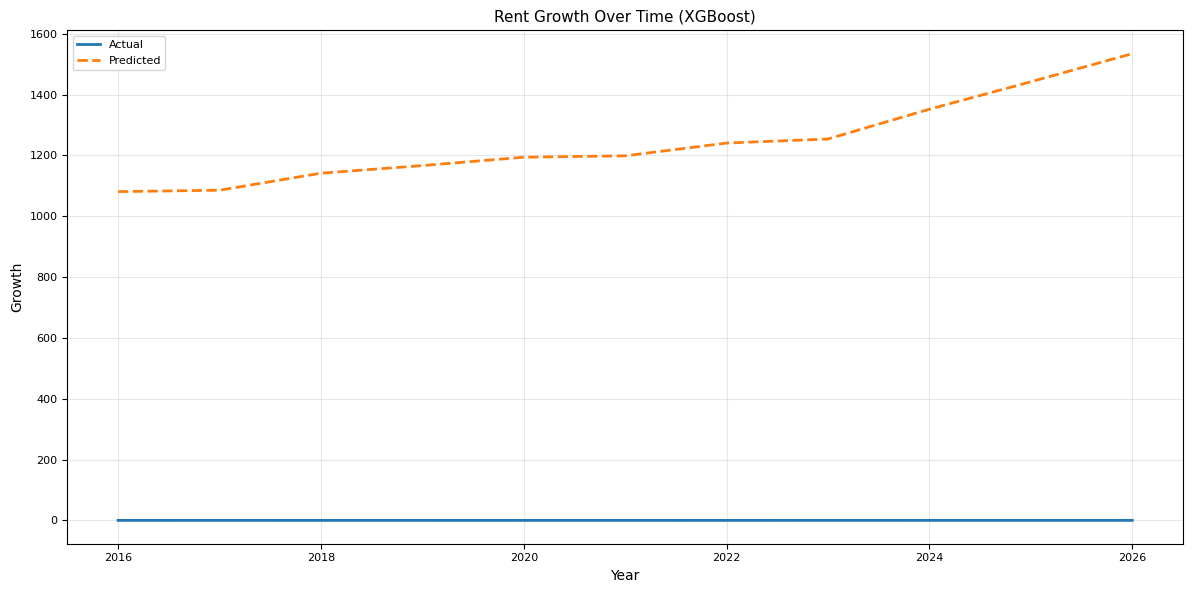

In [38]:
# Time Series Fit

# Aggregate by year
df_plot = test_df.copy()
df_plot["y_pred"] = y_pred

yearly = df_plot.groupby("year")[["rent_growth", "y_pred"]].mean()

plt.figure(figsize=(12, 6))

plt.plot(yearly.index, yearly["rent_growth"], label="Actual", linewidth=2)
plt.plot(yearly.index, yearly["y_pred"], linestyle="--", linewidth=2, label="Predicted")

plt.title("Rent Growth Over Time (XGBoost)")
plt.xlabel("Year")
plt.ylabel("Growth")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

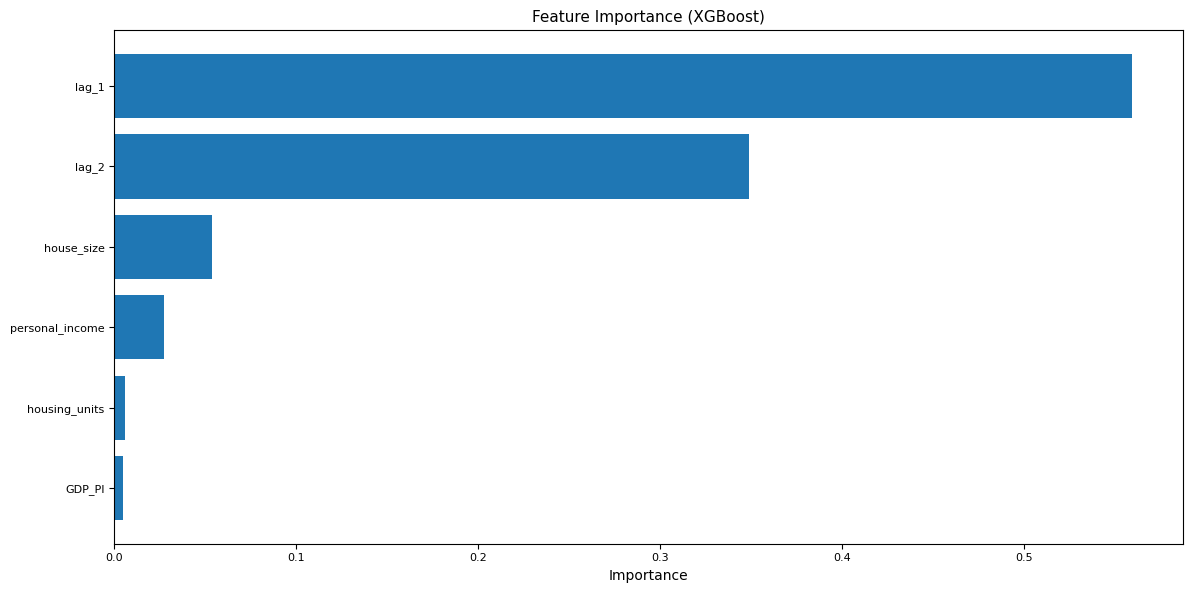

In [39]:
# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 6))

plt.barh(range(len(features)), importances[indices])
plt.yticks(range(len(features)), [features[i] for i in indices])

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# LSTM Model

## Features and Target

In [40]:
# Features Columns
features = [
    "GDP_PI",
    "housing_units",
    "personal_income",
    "house_size",
    "lag_1",
    "lag_2"
]

# Target Columns
target = "rent"


## Data Partitioning

In [41]:
df_model2 = df_long.dropna().copy()

# Data Partitions
train_df = df_model2[df_model2["year"] <= 2015]
test_df  = df_model2[df_model2["year"] > 2015]

## Scaling data


In [42]:
# Scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scaling Training Set
train_df[features] = scaler_X.fit_transform(train_df[features])
train_df[target] = scaler_y.fit_transform(train_df[[target]])

# Scaling Testing Set
test_df[features] = scaler_X.transform(test_df[features])
test_df[target] = scaler_y.transform(test_df[[target]])

/tmp/ipykernel_1610/3202030360.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler_X.fit_transform(train_df[features])
/tmp/ipykernel_1610/3202030360.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[target] = scaler_y.fit_transform(train_df[[target]])
/tmp/ipykernel_1610/3202030360.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

## Creating Sequences

### Train Sequences

In [43]:
# Sequence Lenght
SEQ_LEN = 2

# Sequences
X_train_seq, y_train_seq = [], []

for county in train_df["county_name"].unique():
    county_df = train_df[train_df["county_name"] == county]

    X = county_df[features].values
    y = county_df[target].values

    for i in range(len(county_df) - SEQ_LEN):
        X_train_seq.append(X[i:i+SEQ_LEN])
        y_train_seq.append(y[i+SEQ_LEN])

### Test Sequences

In [44]:
# Sequences
X_test_seq, y_test_seq = [], []

for county in test_df["county_name"].unique():
    county_df = test_df[test_df["county_name"] == county]

    X = county_df[features].values
    y = county_df[target].values

    for i in range(len(county_df) - SEQ_LEN):
        X_test_seq.append(X[i:i+SEQ_LEN])
        y_test_seq.append(y[i+SEQ_LEN])

## Converting to Tensors

In [45]:
# Train Tensors
X_train = torch.tensor(np.array(X_train_seq), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train_seq), dtype=torch.float32)

# Test Tensors
X_test = torch.tensor(np.array(X_test_seq), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test_seq), dtype=torch.float32)

## LSTM Model

In [46]:
# Model Function
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze()


### Model Initialization

In [47]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Model
model = LSTMModel(input_size=len(features)).to(device)


### Training Setup

In [48]:
# Training Setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50
train_losses = []

### Training Loop

In [49]:
# Training Loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        xb = X_train[i].unsqueeze(0).to(device)
        yb = y_train[i].to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")


Epoch 1/50 | Loss: 0.111674
Epoch 2/50 | Loss: 0.079915
Epoch 3/50 | Loss: 0.071908
Epoch 4/50 | Loss: 0.067178
Epoch 5/50 | Loss: 0.063913
Epoch 6/50 | Loss: 0.061240
Epoch 7/50 | Loss: 0.059084
Epoch 8/50 | Loss: 0.057867
Epoch 9/50 | Loss: 0.056328
Epoch 10/50 | Loss: 0.055096
Epoch 11/50 | Loss: 0.054052
Epoch 12/50 | Loss: 0.053124
Epoch 13/50 | Loss: 0.052253
Epoch 14/50 | Loss: 0.051640
Epoch 15/50 | Loss: 0.051040
Epoch 16/50 | Loss: 0.050382
Epoch 17/50 | Loss: 0.049656
Epoch 18/50 | Loss: 0.048905
Epoch 19/50 | Loss: 0.048200
Epoch 20/50 | Loss: 0.047545
Epoch 21/50 | Loss: 0.046897
Epoch 22/50 | Loss: 0.046795
Epoch 23/50 | Loss: 0.047124
Epoch 24/50 | Loss: 0.047455
Epoch 25/50 | Loss: 0.047094
Epoch 26/50 | Loss: 0.045884
Epoch 27/50 | Loss: 0.046068
Epoch 28/50 | Loss: 0.045584
Epoch 29/50 | Loss: 0.044716
Epoch 30/50 | Loss: 0.044659
Epoch 31/50 | Loss: 0.044663
Epoch 32/50 | Loss: 0.044630
Epoch 33/50 | Loss: 0.045274
Epoch 34/50 | Loss: 0.045405
Epoch 35/50 | Loss: 0.0

### Loss Curve

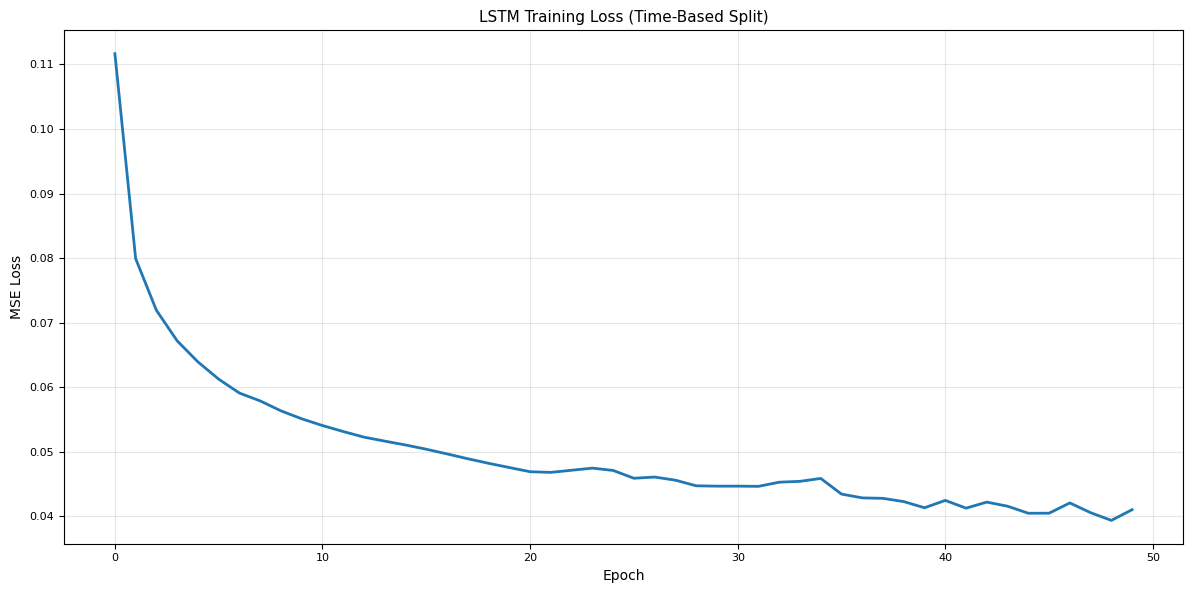

In [50]:
# Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_losses, linewidth=2)

plt.title("LSTM Training Loss (Time-Based Split)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Predictions

In [51]:
# Predictions
model.eval()

preds = []

with torch.no_grad():
    for i in range(len(X_test)):
        xb = X_test[i].unsqueeze(0).to(device)
        pred = model(xb).cpu().numpy()
        preds.append(pred)

preds = np.array(preds).flatten()


### Evaluation

In [52]:
# Inverse Transform
y_test_np = y_test.numpy().flatten()

preds_inv = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
y_test_inv = scaler_y.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

In [53]:
# Performance Evaluation
rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
mae = mean_absolute_error(y_test_inv, preds_inv)
r2 = r2_score(y_test_inv, preds_inv)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")

RMSE: 484.892804
MAE:  278.995544
R²:   0.4991


### Diagnostic Plots

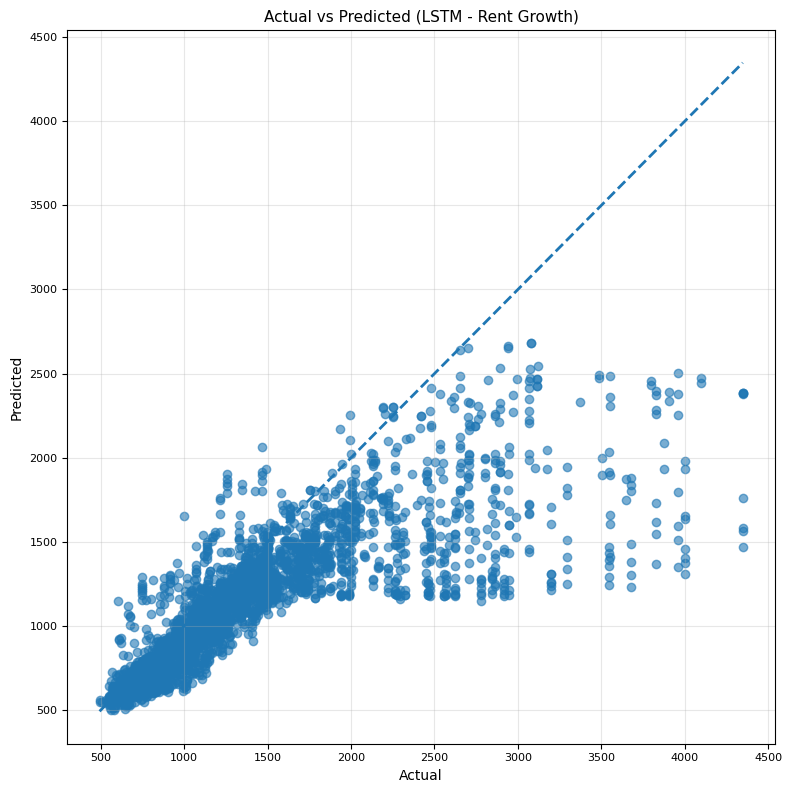

In [54]:
# Actual vs Predicted

plt.figure(figsize=(8, 8))

plt.scatter(y_test_inv, preds_inv, alpha=0.6)

# Perfect prediction line
min_v = min(y_test_inv.min(), preds_inv.min())
max_v = max(y_test_inv.max(), preds_inv.max())

plt.plot([min_v, max_v], [min_v, max_v], '--', linewidth=2)

plt.title("Actual vs Predicted (LSTM - Rent Growth)")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


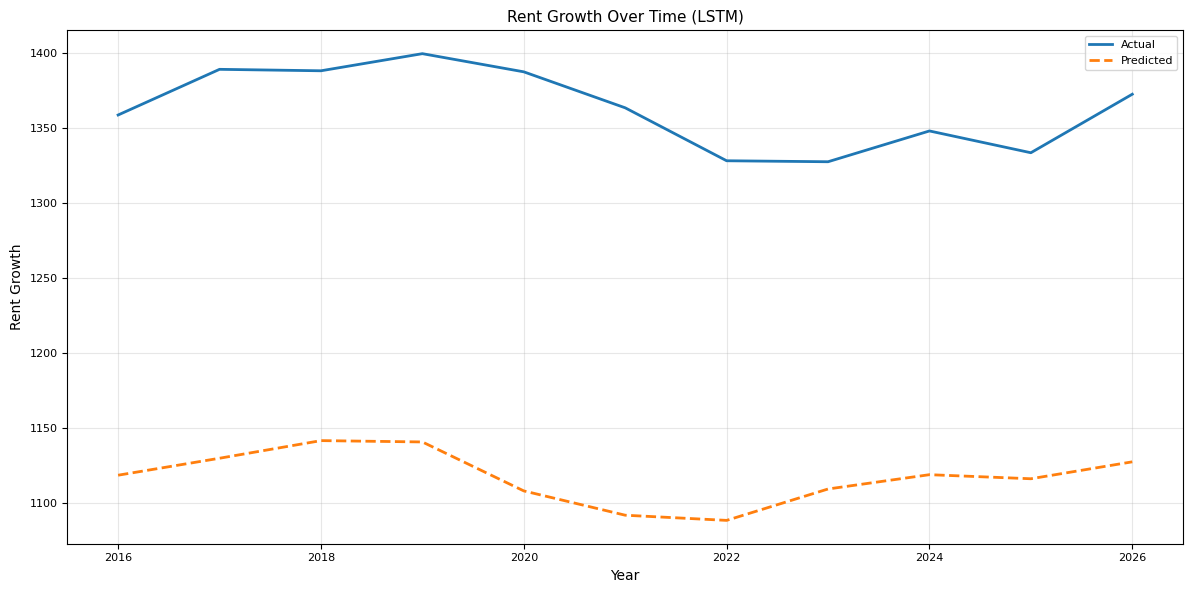

In [55]:
# Time Series Plot

# Inverse transformed
results_df = test_df.copy().iloc[:len(preds_inv)]
results_df["actual"] = y_test_inv
results_df["predicted"] = preds_inv
# Aggregate by year
yearly = results_df.groupby("year")[["actual", "predicted"]].mean()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(yearly.index, yearly["actual"], label="Actual", linewidth=2)
plt.plot(yearly.index, yearly["predicted"], label="Predicted", linestyle="--", linewidth=2)

plt.title("Rent Growth Over Time (LSTM)")
plt.xlabel("Year")
plt.ylabel("Rent Growth")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


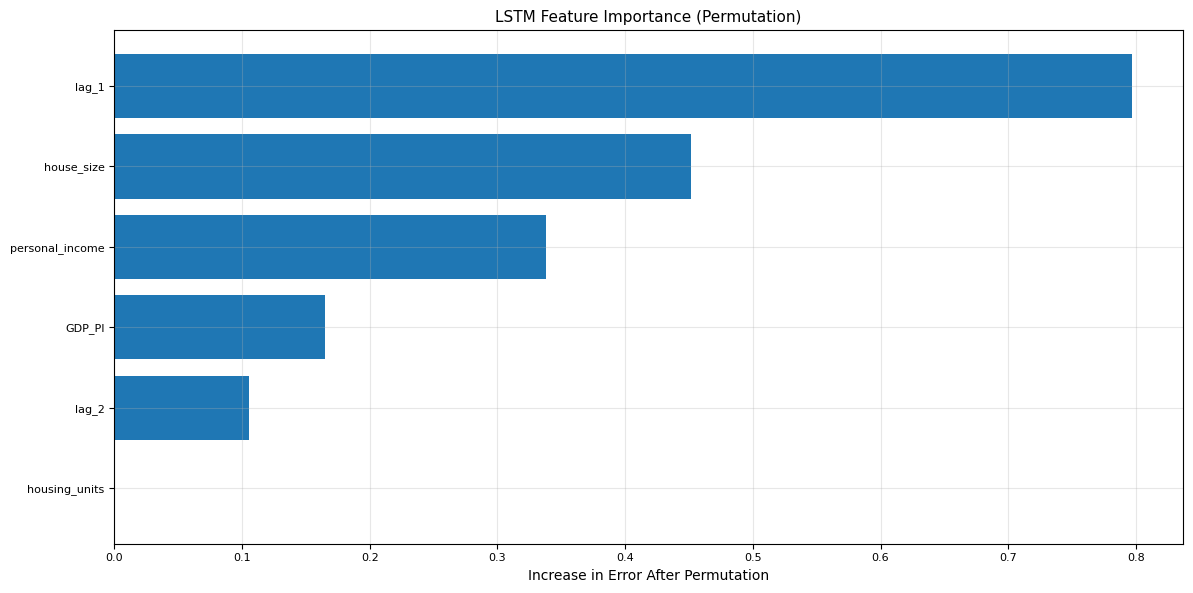

In [58]:
# Feature Importance

# Function
def permutation_importance_lstm(model, X_test, y_test, feature_names):
    baseline_preds = []

    model.eval()
    with torch.no_grad():
        for i in range(len(X_test)):
            xb = X_test[i].unsqueeze(0).to(device)
            pred = model(xb).cpu().numpy()
            baseline_preds.append(pred)

    baseline_preds = np.array(baseline_preds).flatten()
    baseline_loss = mean_squared_error(y_test, baseline_preds)

    importances = []

    for i, feature in enumerate(feature_names):
        X_perm = X_test.clone()

        # shuffle feature i across all sequences
        idx = torch.randperm(X_perm.size(0))
        X_perm[:, :, i] = X_perm[idx, :, i]

        preds = []

        with torch.no_grad():
            for j in range(len(X_perm)):
                xb = X_perm[j].unsqueeze(0).to(device)
                pred = model(xb).cpu().numpy()
                preds.append(pred)

        preds = np.array(preds).flatten()
        loss = mean_squared_error(y_test, preds)

        importances.append(abs(loss - baseline_loss))

    return importances

# Getting Importances
feature_names = features

importances = permutation_importance_lstm(
    model,
    X_test,
    y_test.numpy().flatten(),
    feature_names
)

# Plot
plt.figure(figsize=(12, 6))

idx = np.argsort(importances)

plt.barh(range(len(feature_names)), np.array(importances)[idx])
plt.yticks(range(len(feature_names)), np.array(feature_names)[idx])

plt.title("LSTM Feature Importance (Permutation)")
plt.xlabel("Increase in Error After Permutation")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



